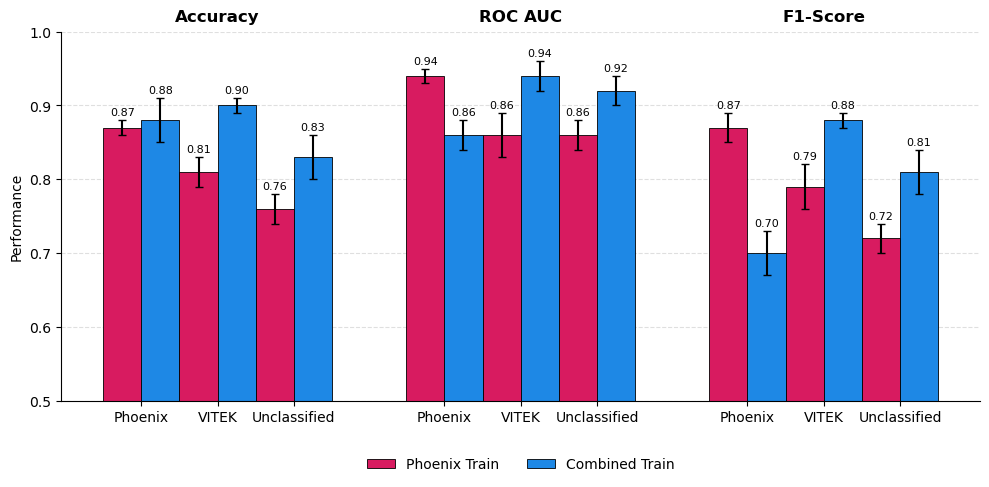

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

mean_df = pd.read_csv("diagram_data/results_strict.csv")
std_df = pd.read_csv("diagram_data/results_strict_std.csv")

metrics = ["Accuracy", "ROC AUC", "F1-Score"]
test_sets = ["Phoenix Test", "VITEK Test", "Unclassified Test"]

colors = {
    "Phoenix Train": "#D81B60",
    "Combined Train": "#1E88E5",
}

fig, ax = plt.subplots(figsize=(10, 5))

width = 0.18
group_gap = 0.35

x_positions = []
x_labels = []

for m_idx, metric in enumerate(metrics):

    metric_mean = mean_df[mean_df["Metric"] == metric]
    metric_std = std_df[std_df["Metric"] == metric]

    base = m_idx * (len(test_sets) * 2 * width + group_gap)

    for t_idx, test in enumerate(test_sets):

        x = base + t_idx * (2 * width)

        for offset, train in zip(
            [-width / 2, width / 2], ["Phoenix Train", "Combined Train"]
        ):

            mean = metric_mean.loc[metric_mean["Train set"] == train, test].iloc[0]

            std = metric_std.loc[metric_std["Train set"] == train, test].iloc[0]

            bars = ax.bar(
                x + offset,
                mean,
                width,
                yerr=std,
                capsize=3,
                color=colors[train],
                edgecolor="black",
                linewidth=0.6,
                label=train if (m_idx == 0 and t_idx == 0) else None,
            )

            ax.bar_label(
                bars,
                fmt="%.2f",
                fontsize=8,
                padding=2,
            )

        x_positions.append(x)
        x_labels.append(test.replace(" Test", ""))

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

for m_idx, metric in enumerate(metrics):
    center = m_idx * (len(test_sets) * 2 * width + group_gap) + 2 * width
    ax.text(
        center,
        1.02,
        metric,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        transform=ax.get_xaxis_transform(),
    )

ax.set_ylabel("Performance")
ax.set_ylim(0.5, 1.0)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False,
)

plt.tight_layout()

plt.savefig(
    "diagram_data/experiment_5_results_strict.pdf", dpi=600, bbox_inches="tight"
)
plt.savefig(
    "diagram_data/experiment_5_results_strict.jpg", dpi=600, bbox_inches="tight"
)
plt.show()

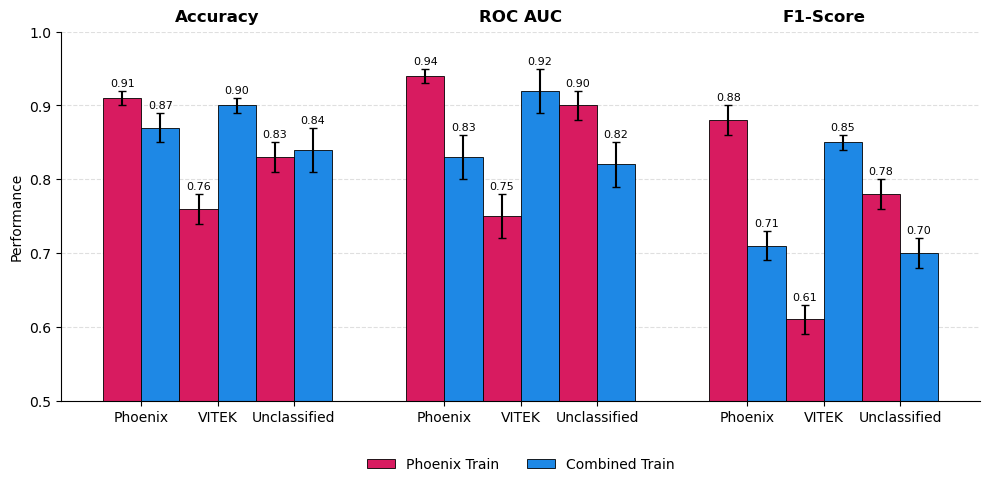

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

mean_df = pd.read_csv("diagram_data/results_loose.csv")
std_df = pd.read_csv("diagram_data/results_loose_std.csv")

metrics = ["Accuracy", "ROC AUC", "F1-Score"]
test_sets = ["Phoenix Test", "VITEK Test", "Unclassified Test"]

colors = {
    "Phoenix Train": "#D81B60",
    "Combined Train": "#1E88E5",
}

fig, ax = plt.subplots(figsize=(10, 5))

width = 0.18
group_gap = 0.35

x_positions = []
x_labels = []

for m_idx, metric in enumerate(metrics):

    metric_mean = mean_df[mean_df["Metric"] == metric]
    metric_std = std_df[std_df["Metric"] == metric]

    base = m_idx * (len(test_sets) * 2 * width + group_gap)

    for t_idx, test in enumerate(test_sets):

        x = base + t_idx * (2 * width)

        for offset, train in zip(
            [-width / 2, width / 2], ["Phoenix Train", "Combined Train"]
        ):

            mean = metric_mean.loc[metric_mean["Train set"] == train, test].iloc[0]

            std = metric_std.loc[metric_std["Train set"] == train, test].iloc[0]

            bars = ax.bar(
                x + offset,
                mean,
                width,
                yerr=std,
                capsize=3,
                color=colors[train],
                edgecolor="black",
                linewidth=0.6,
                label=train if (m_idx == 0 and t_idx == 0) else None,
            )

            ax.bar_label(
                bars,
                fmt="%.2f",
                fontsize=8,
                padding=2,
            )

        x_positions.append(x)
        x_labels.append(test.replace(" Test", ""))

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

for m_idx, metric in enumerate(metrics):
    center = m_idx * (len(test_sets) * 2 * width + group_gap) + 2 * width
    ax.text(
        center,
        1.02,
        metric,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        transform=ax.get_xaxis_transform(),
    )

ax.set_ylabel("Performance")
ax.set_ylim(0.5, 1.0)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False,
)

plt.tight_layout()

plt.savefig("diagram_data/experiment_5_results_loose.pdf", dpi=600, bbox_inches="tight")
plt.savefig("diagram_data/experiment_5_results_loose.jpg", dpi=600, bbox_inches="tight")
plt.show()

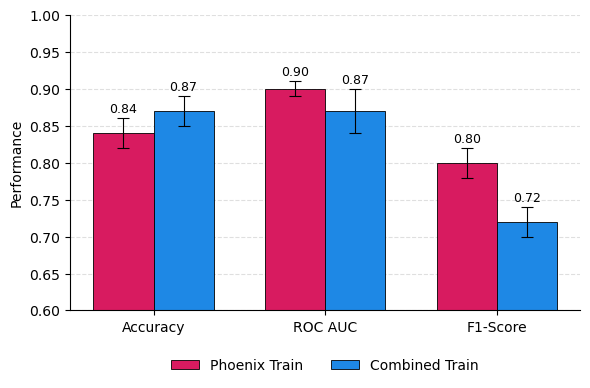

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

mean_df = pd.read_csv("diagram_data/results_loose_median.csv")
std_df = pd.read_csv("diagram_data/results_loose_median_std.csv")

metrics = ["Accuracy", "ROC AUC", "F1-Score"]

colors = {
    "Phoenix Train": "#D81B60",
    "Combined Train": "#1E88E5",
}

fig, ax = plt.subplots(figsize=(6, 4))

width = 0.35
x = np.arange(len(metrics))

for i, train in enumerate(mean_df["Overall"]):

    offset = (-0.5 + i) * width

    values = mean_df.loc[i, metrics].values.astype(float)
    errors = std_df.loc[i, metrics].values.astype(float)

    bars = ax.bar(
        x + offset,
        values,
        width,
        yerr=errors,
        capsize=4,
        error_kw={
            "elinewidth": 0.8,
            "capthick": 0.8,
        },
        color=colors[train.strip()],
        edgecolor="black",
        linewidth=0.6,
        label=train.strip(),
    )

    ax.bar_label(
        bars,
        fmt="%.2f",
        fontsize=9,
        padding=2,
    )

ax.set_xticks(x)
ax.set_xticklabels(["Accuracy", "ROC AUC", "F1-Score"])

ax.set_ylabel("Performance")
ax.set_ylim(0.6, 1.0)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False,
)

plt.tight_layout()

plt.savefig("diagram_data/results_loose_median.pdf", dpi=600, bbox_inches="tight")
plt.savefig("diagram_data/results_loose_median.jpg", dpi=600, bbox_inches="tight")

plt.show()

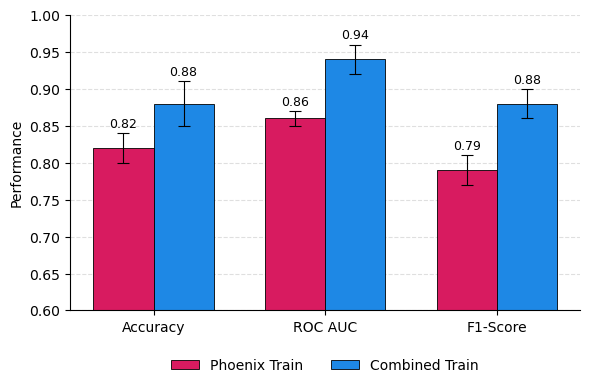

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

mean_df = pd.read_csv("diagram_data/results_strict_median.csv")
std_df = pd.read_csv("diagram_data/results_strict_median_std.csv")

metrics = ["Accuracy", "ROC AUC", "F1-Score"]

colors = {
    "Phoenix Train": "#D81B60",
    "Combined Train": "#1E88E5",
}

fig, ax = plt.subplots(figsize=(6, 4))

width = 0.35
x = np.arange(len(metrics))

for i, train in enumerate(mean_df["Overall"]):

    offset = (-0.5 + i) * width

    values = mean_df.loc[i, metrics].values.astype(float)
    errors = std_df.loc[i, metrics].values.astype(float)

    bars = ax.bar(
        x + offset,
        values,
        width,
        yerr=errors,
        capsize=4,
        error_kw={
            "elinewidth": 0.8,
            "capthick": 0.8,
        },
        color=colors[train.strip()],
        edgecolor="black",
        linewidth=0.6,
        label=train.strip(),
    )

    ax.bar_label(
        bars,
        fmt="%.2f",
        fontsize=9,
        padding=2,
    )

ax.set_xticks(x)
ax.set_xticklabels(["Accuracy", "ROC AUC", "F1-Score"])

ax.set_ylabel("Performance")
ax.set_ylim(0.6, 1.0)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False,
)

plt.tight_layout()

plt.savefig("diagram_data/results_strict_median.pdf", dpi=600, bbox_inches="tight")
plt.savefig("diagram_data/results_strict_median.jpg", dpi=600, bbox_inches="tight")

plt.show()